<a href="https://colab.research.google.com/github/NehaBiswas26/Customer_churn_analysis-/blob/main/customer_churn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROJECT:CUSTOMER CHURN PREDICTION


PROJECT SUMMARY:

Customer Churn Prediction is a Python-based data analytics and machine learning project. The project analyzes customer information and predicts whether a customer is likely to leave a bank. It uses customer attributes such as credit score, age, balance, tenure, number of products, and activity status. Machine learning algorithms are used to identify patterns related to customer churn.

Problem Description:

Banks need to identify customers who are likely to leave their services. Losing customers can affect the bank's revenue and growth. Therefore, this project aims to analyze customer data and build a machine learning model that can predict whether a customer will stay or leave the bank

Data Description:

The project uses the Churn Modelling dataset, which contains information about bank customers. The dataset includes customer demographic, financial, and account-related information. The target attribute is Exited, where 0 represents a customer who stayed and 1 represents a customer who left.

Attribute Information:

Attribute	Description
RowNumber	Row number of the customer
CustomerId	Unique customer ID
Surname	Customer surname
CreditScore	Customer's credit score
Geography	Customer's country/region
Gender	Customer's gender
Age	Customer's age
Tenure	Number of years with the bank
Balance	Customer's account balance
NumOfProducts	Number of bank products used
HasCrCard	Whether the customer has a credit card
IsActiveMember	Whether the customer is an active member
EstimatedSalary	Estimated customer salary
Exited	Whether the customer left the bank

DATA CLEANING:


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/archive.zip")

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 14


In [ ]:
print(df.columns)


Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:
print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


Data Analysis:

In [ ]:
print(df["Exited"].value_counts())


Exited
0    7963
1    2037
Name: count, dtype: int64


In [ ]:
print("Average Age:", df["Age"].mean())

Average Age: 38.9218


In [ ]:
print("Average Credit Score:", df["CreditScore"].mean())

Average Credit Score: 650.5288


In [ ]:
print("Average Balance:", df["Balance"].mean())

Average Balance: 76485.889288


In [ ]:
print(df.groupby("Gender")["Exited"].mean() * 100)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


In [ ]:
print(df.groupby("Geography")["Exited"].mean() * 100)

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


In [ ]:
print(df.groupby("IsActiveMember")["Exited"].mean() * 100)

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [ ]:
print(df.groupby("NumOfProducts")["Exited"].mean() * 100)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [ ]:
print(df.groupby("HasCrCard")["Exited"].mean() * 100)

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64


In [ ]:
print(df.groupby("Exited")[[
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]].mean())

        CreditScore        Age    Tenure       Balance  NumOfProducts  \
Exited                                                                  
0        651.853196  37.408389  5.033279  72745.296779       1.544267   
1        645.351497  44.837997  4.932744  91108.539337       1.475209   

        EstimatedSalary  
Exited                   
0          99738.391772  
1         101465.677531  


In [ ]:
correlation = df.corr(numeric_only=True)

print(correlation["Exited"].sort_values(ascending=False))

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
CustomerId        -0.006248
HasCrCard         -0.007138
Tenure            -0.014001
RowNumber         -0.016571
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


DATA VISUALIZATION:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

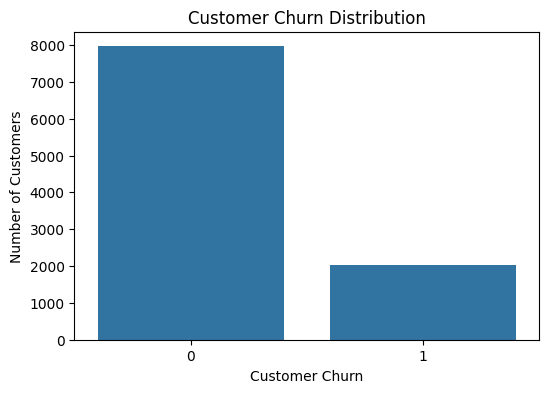

In [ ]:
plt.figure(figsize=(6, 4)) # Set the figure size for the plot

sns.countplot(x="Exited", data=df) # Create a count plot of the 'Exited' column

plt.title("Customer Churn Distribution") # Set the title of the plot
plt.xlabel("Customer Churn") # Set the label for the x-axis
plt.ylabel("Number of Customers") # Set the label for the y-axis

plt.show() # Display the plot

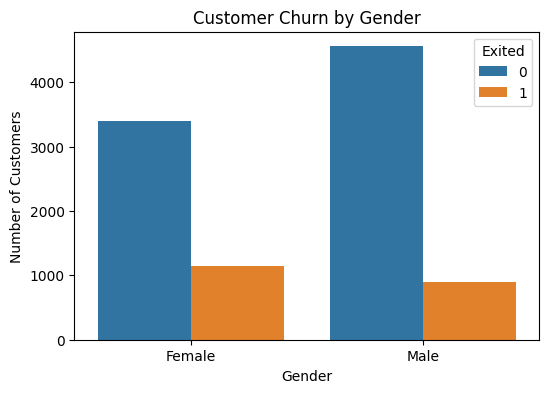

In [ ]:
plt.figure(figsize=(6, 4)) # Set the figure size for the plot

sns.countplot(x="Gender", hue="Exited", data=df) # Create a count plot of churned vs. non-churned customers by gender

plt.title("Customer Churn by Gender") # Set the title of the plot
plt.xlabel("Gender") # Set the label for the x-axis
plt.ylabel("Number of Customers") # Set the label for the y-axis

plt.show() # Display the plot

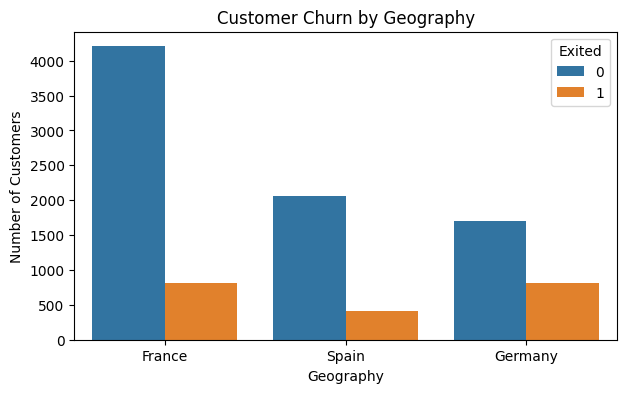

In [ ]:
plt.figure(figsize=(7, 4)) # Set the figure size for the plot

sns.countplot(x="Geography", hue="Exited", data=df) # Create a count plot of churned vs. non-churned customers by geography

plt.title("Customer Churn by Geography") # Set the title of the plot
plt.xlabel("Geography") # Set the label for the x-axis
plt.ylabel("Number of Customers") # Set the label for the y-axis

plt.show() # Display the plot

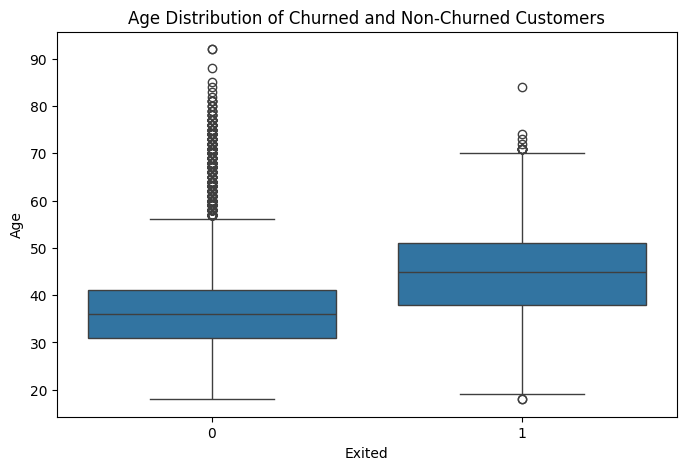

In [ ]:
plt.figure(figsize=(8, 5)) # Set the figure size for the plot

sns.boxplot(x="Exited", y="Age", data=df) # Create a box plot to show age distribution for churned and non-churned customers

plt.title("Age Distribution of Churned and Non-Churned Customers") # Set the title of the plot
plt.xlabel("Exited") # Set the label for the x-axis
plt.ylabel("Age") # Set the label for the y-axis

plt.show() # Display the plot

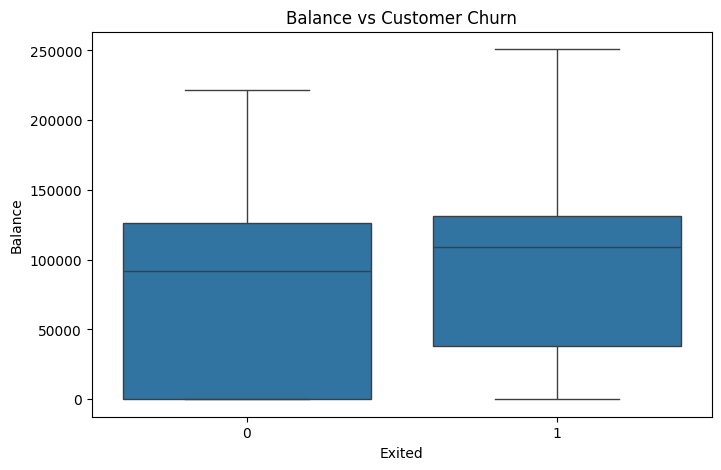

In [ ]:
plt.figure(figsize=(8, 5)) # Set the figure size for the plot

sns.boxplot(x="Exited", y="Balance", data=df) # Create a box plot to show balance distribution for churned and non-churned customers

plt.title("Balance vs Customer Churn") # Set the title of the plot
plt.xlabel("Exited") # Set the label for the x-axis
plt.ylabel("Balance") # Set the label for the y-axis

plt.show() # Display the plot

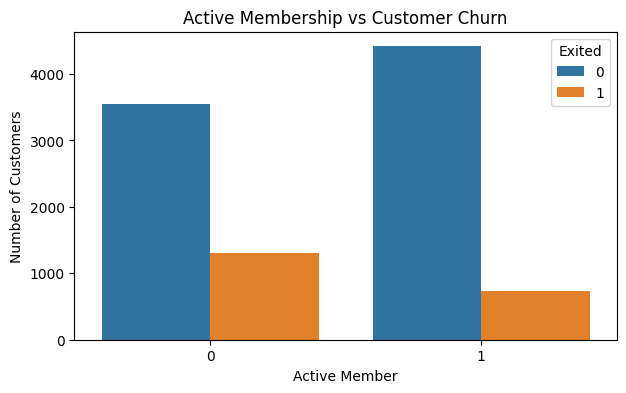

In [ ]:
plt.figure(figsize=(7, 4)) # Set the figure size for the plot

sns.countplot(x="IsActiveMember", hue="Exited", data=df) # Create a count plot of churned vs. non-churned customers by active membership status

plt.title("Active Membership vs Customer Churn") # Set the title of the plot
plt.xlabel("Active Member") # Set the label for the x-axis
plt.ylabel("Number of Customers") # Set the label for the y-axis

plt.show() # Display the plot

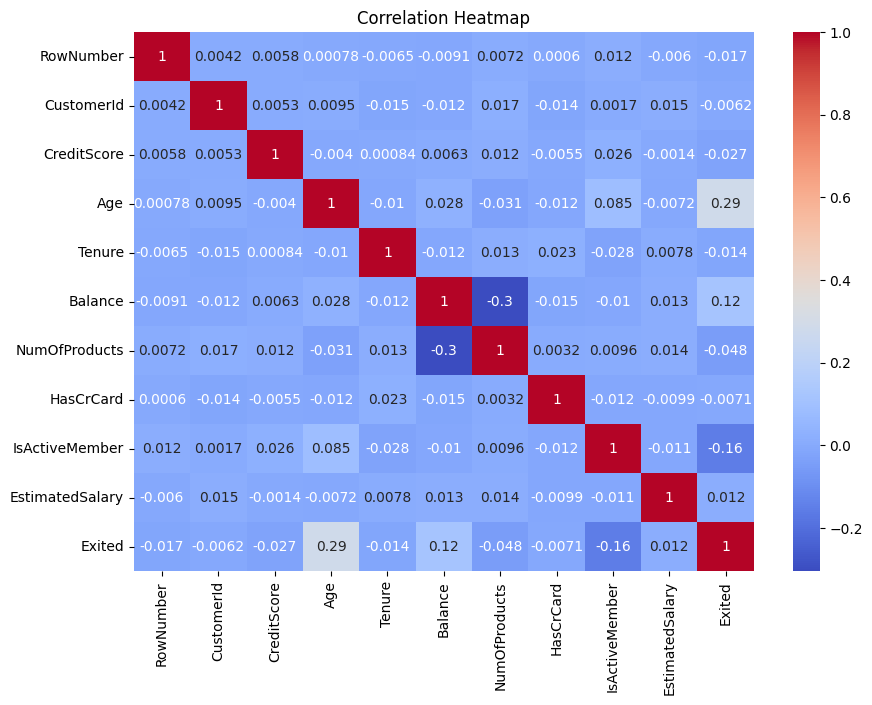

In [ ]:
plt.figure(figsize=(10, 7)) # Set the figure size for the plot

correlation = df.corr(numeric_only=True) # Calculate the correlation matrix for numerical columns

sns.heatmap(
    correlation, # Data for the heatmap
    annot=True, # Display correlation values on the heatmap
    cmap="coolwarm" # Choose the color map
) # Create a heatmap to visualize the correlation matrix

plt.title("Correlation Heatmap") # Set the title of the plot

plt.show() # Display the plot

### Distribution of Key Features by Churn Status

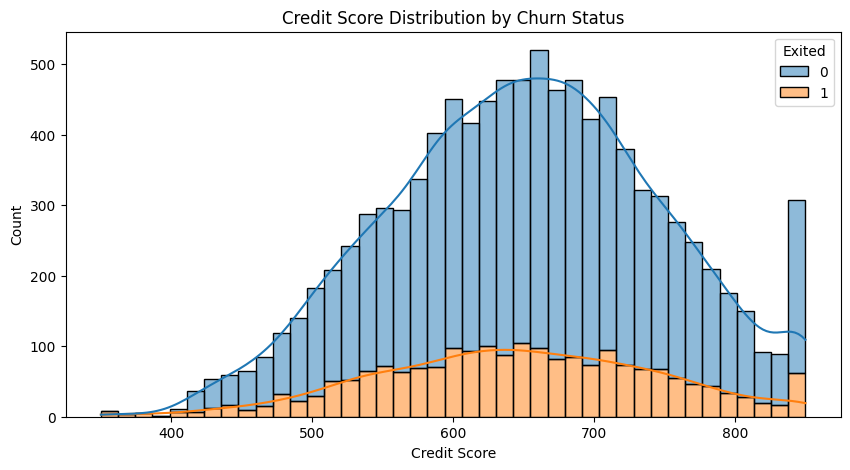

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df, x='CreditScore', hue='Exited', multiple='stack', kde=True)
plt.title('Credit Score Distribution by Churn Status')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.show()

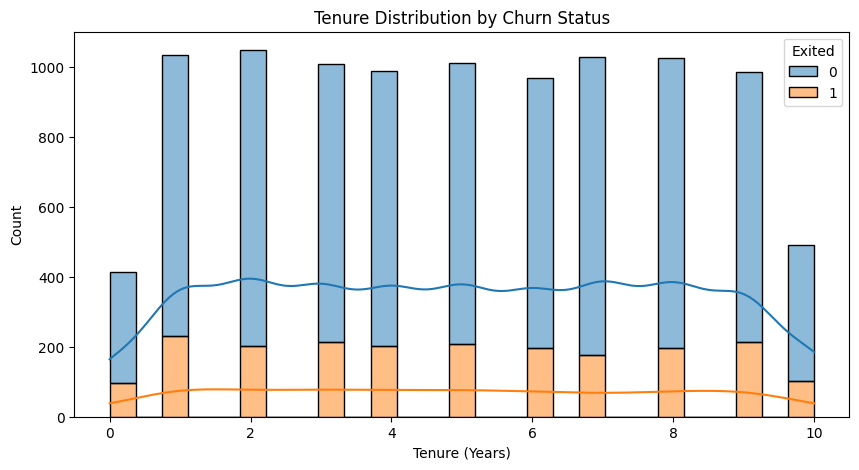

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df, x='Tenure', hue='Exited', multiple='stack', kde=True)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Years)')
plt.ylabel('Count')
plt.show()

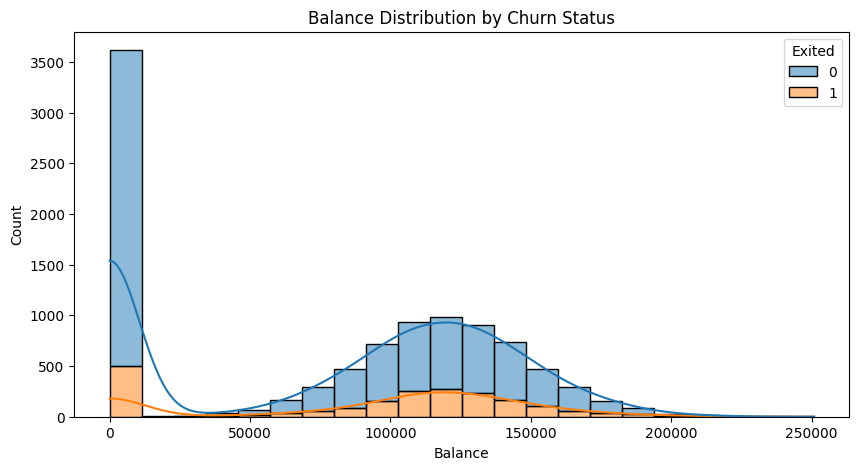

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df, x='Balance', hue='Exited', multiple='stack', kde=True)
plt.title('Balance Distribution by Churn Status')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.show()

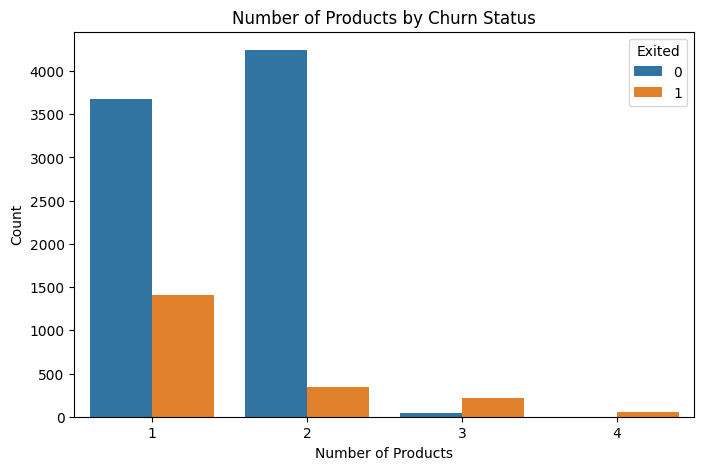

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title('Number of Products by Churn Status')
plt.xlabel('Number of Products')
plt.ylabel('Count')
plt.show()

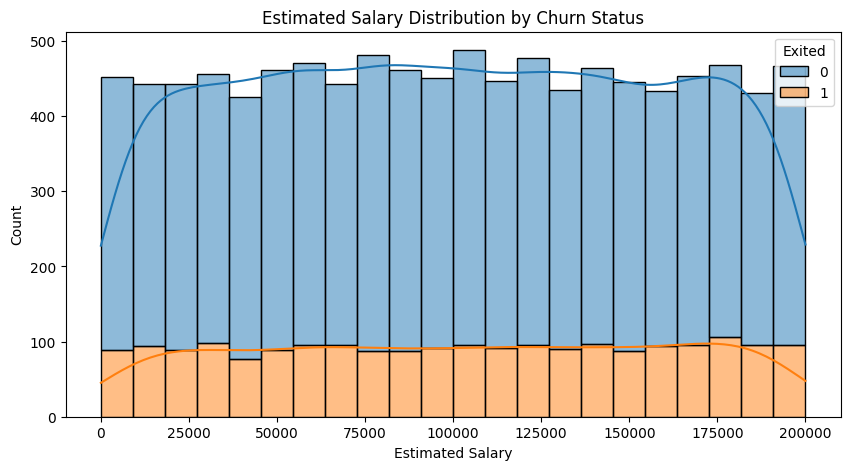

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df, x='EstimatedSalary', hue='Exited', multiple='stack', kde=True)
plt.title('Estimated Salary Distribution by Churn Status')
plt.xlabel('Estimated Salary')
plt.ylabel('Count')
plt.show()

### Pairplot of Numerical Features vs. Churn Status

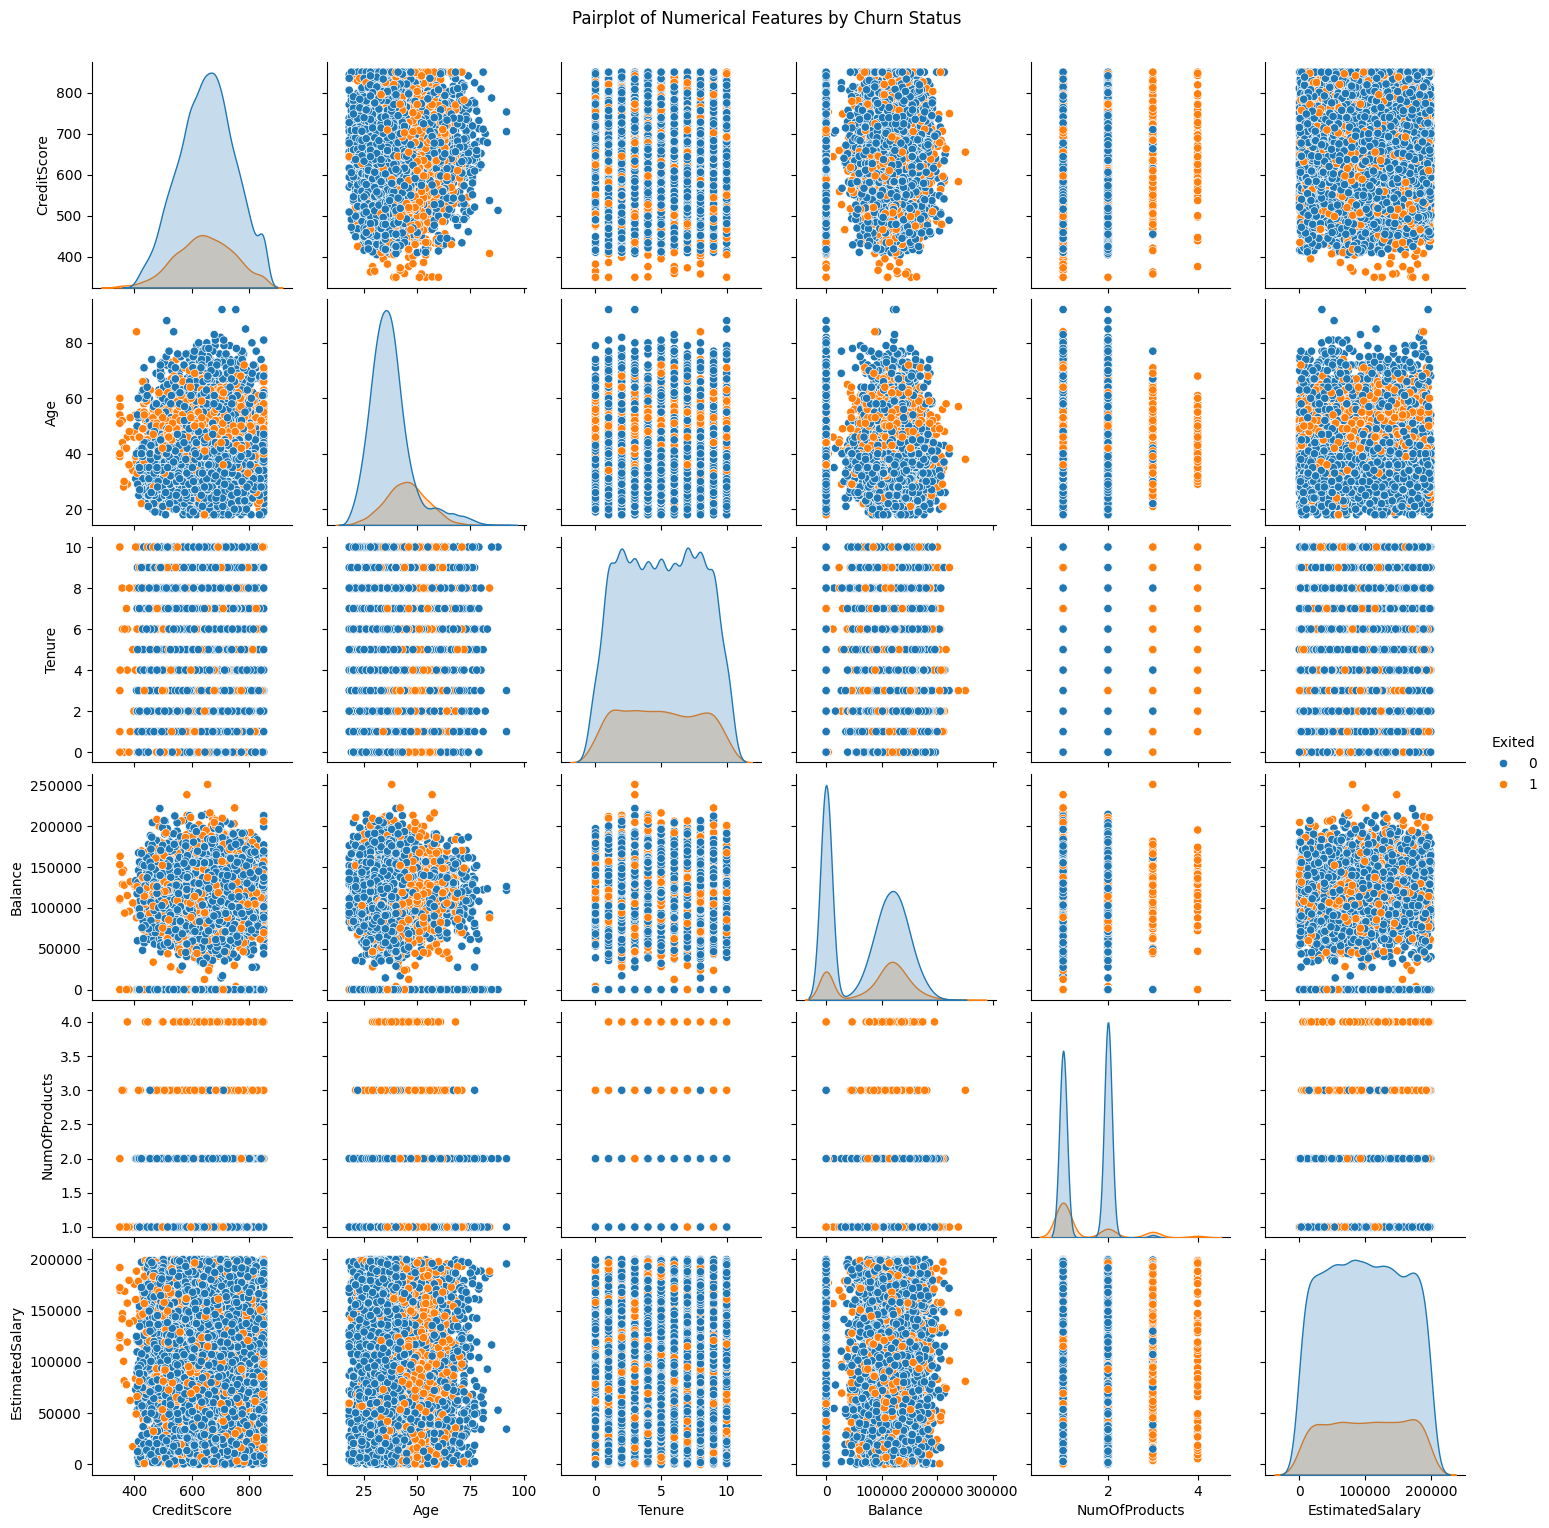

In [ ]:
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
sns.pairplot(df[numerical_features + ['Exited']], hue='Exited', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by Churn Status', y=1.02) # Adjust suptitle position
plt.show()

### Feature Selection and Preprocessing

Feature selection is the process of choosing the most relevant features from your dataset for model training. Irrelevant or redundant features can lead to decreased model performance, increased training time, and more complex models. Preprocessing involves transforming the data into a format suitable for machine learning algorithms, such as converting categorical variables into numerical representations.

In [ ]:
# Drop irrelevant columns that are not useful for prediction
df_processed = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("DataFrame after dropping irrelevant columns:")
display(df_processed.head())

DataFrame after dropping irrelevant columns:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Next, we will handle categorical variables (`Geography` and `Gender`) using one-hot encoding. This process converts categorical data into a numerical format that machine learning algorithms can understand, by creating new binary columns for each category.

In [ ]:
# Apply one-hot encoding to categorical features: 'Geography' and 'Gender'
df_processed = pd.get_dummies(df_processed, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

print("DataFrame after one-hot encoding:")
display(df_processed.head())
print(f"Shape of the processed DataFrame: {df_processed.shape}")

DataFrame after one-hot encoding:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


Shape of the processed DataFrame: (10000, 12)


### Data Splitting and Scaling

Before training any machine learning model, it's essential to split the dataset into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data. This helps in assessing how well the model generalizes.

Additionally, numerical features often benefit from scaling. Standardization (using `StandardScaler`) transforms the data so that it has a mean of 0 and a standard deviation of 1. This prevents features with larger values from dominating the learning process and helps many machine learning algorithms converge faster.

In [ ]:
# Separate features (X) and target variable (y)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (8000, 11)
Shape of X_test: (2000, 11)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


Now, we will apply feature scaling to the numerical columns using `StandardScaler`. This is done after splitting the data to prevent data leakage from the test set into the training process.

In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical columns for scaling (exclude one-hot encoded and target columns)
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Fit the scaler on the training data and transform both training and test data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train after scaling numerical features:")
display(X_train.head())
print("X_test after scaling numerical features:")
display(X_test.head())

X_train after scaling numerical features:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2151,1.058568,1.715086,0.684723,-1.226059,-0.910256,1,0,1.042084,0,0,1
8392,0.913626,-0.659935,-0.696202,0.413288,-0.910256,1,0,-0.623556,1,0,1
5006,1.079274,-0.184931,-1.731895,0.601687,0.808830,1,1,0.308128,1,0,0
4117,-0.929207,-0.184931,-0.005739,-1.226059,0.808830,1,0,-0.290199,0,0,1
7182,0.427035,0.955079,0.339492,0.548318,0.808830,0,1,0.135042,1,0,1


X_test after scaling numerical features:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
5702,-0.680735,-0.279932,0.684723,-1.226059,0.808830,1,0,-0.095021,0,0,1
3667,-1.301915,-0.564935,-0.350971,0.877113,0.808830,0,0,-0.778941,1,0,1
1617,-0.970619,0.100072,-0.350971,-1.226059,0.808830,0,1,0.099469,0,1,0
5673,-0.121674,-0.469934,-0.005739,1.011458,0.808830,0,0,-1.147374,0,1,1
4272,-0.111321,-0.469934,-0.696202,0.023204,-0.910256,1,1,1.200283,0,1,0


### Model Training: Logistic Regression

Logistic Regression is a statistical model that in its basic form uses a logistic function to model a binary dependent variable. It's a good choice for binary classification problems like predicting customer churn and serves as an excellent baseline model due to its simplicity and interpretability.

In [ ]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions completed successfully!")
print(y_pred[:10])

Predictions completed successfully!
[0 0 0 0 0 0 0 0 0 0]


###Model Evaluation

In [ ]:
#  Model Evaluation

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# --- Start: Data Preparation (Copied from previous cells to ensure definitions) ---
# Load the dataset
df = pd.read_csv("/content/archive.zip")

# Drop irrelevant columns
df_processed = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Apply one-hot encoding to categorical features
df_processed = pd.get_dummies(df_processed, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

# Separate features (X) and target variable (y)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize StandardScaler and scale numerical features
scaler = StandardScaler()
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
# --- End: Data Preparation ---

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation Results
------------------------
Accuracy : 0.808
Precision: 0.5891472868217055
Recall   : 0.18673218673218672
F1 Score : 0.2835820895522388

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



###Confusion Matrix

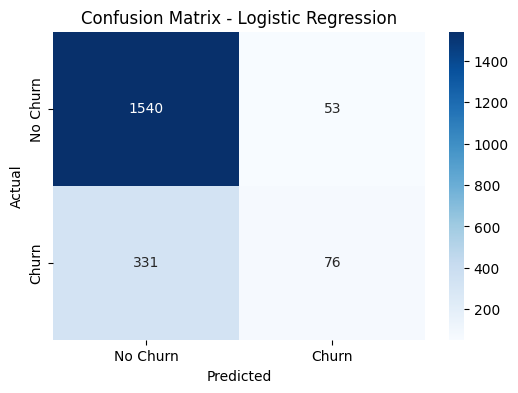

In [ ]:
# Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

###ROC Curve and AUC Score

AUC Score: 0.774824130756334


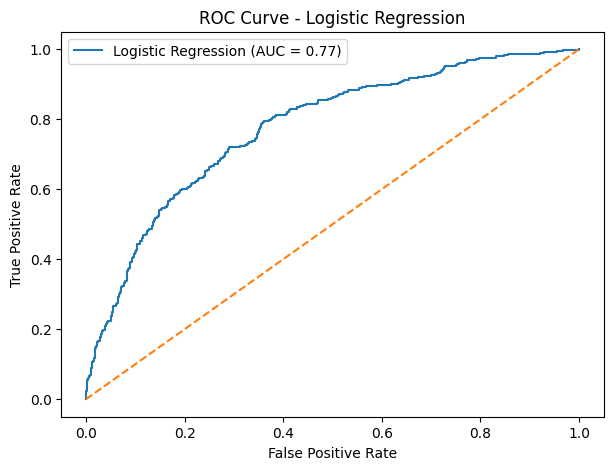

In [ ]:
# ROC Curve and AUC Score

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability prediction
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

Decision Tree Model Training

In [ ]:
#  Decision Tree Model Training

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
decision_tree.fit(X_train, y_train)

print("Decision Tree model training completed successfully!")

Decision Tree model training completed successfully!


In [ ]:
# Decision Tree Prediction

dt_pred = decision_tree.predict(X_test)

print("Decision Tree prediction completed successfully!")

Decision Tree prediction completed successfully!


In [ ]:
# STEP 13: Decision Tree Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
dt_pred = decision_tree.predict(X_test)

# Calculate metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Evaluation Results")
print("--------------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Evaluation Results
--------------------------------
Accuracy : 0.856
Precision: 0.7874396135265701
Recall   : 0.4004914004914005
F1 Score : 0.5309446254071661

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1593
           1       0.79      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000



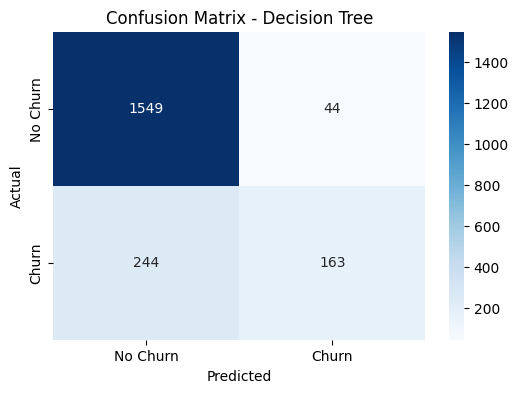

In [ ]:
# Decision Tree Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [ ]:
# STEP 14: Model Comparison

import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, dt_accuracy],
    "Precision": [precision, dt_precision],
    "Recall": [recall, dt_recall],
    "F1 Score": [f1, dt_f1]
})

print(model_comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.808   0.589147  0.186732  0.283582
1        Decision Tree     0.856   0.787440  0.400491  0.530945


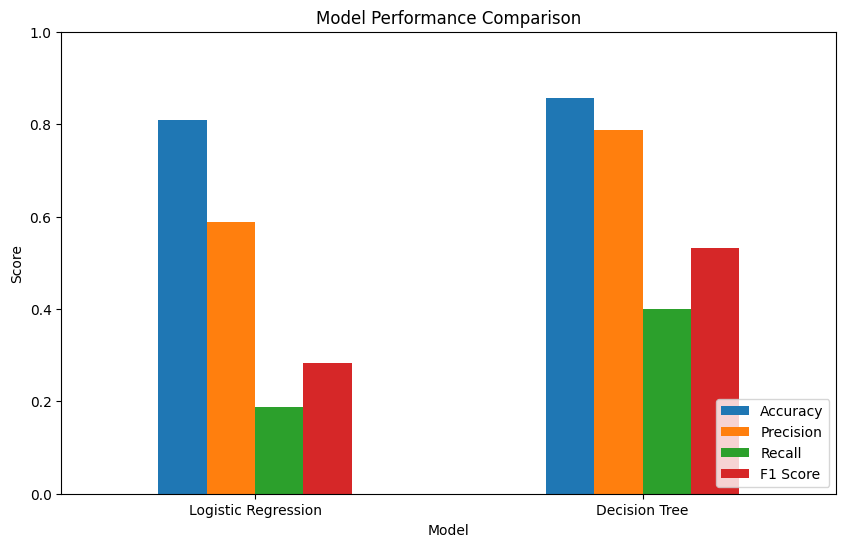

In [ ]:
# Model Comparison Visualization

model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [ ]:
# STEP 15: Best Model Selection

# Select model based on F1 Score
if f1 >= dt_f1:
    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_score = f1
else:
    best_model = decision_tree
    best_model_name = "Decision Tree"
    best_score = dt_f1

print("Best Model:", best_model_name)
print("Best F1 Score:", best_score)

Best Model: Decision Tree
Best F1 Score: 0.5309446254071661


In [ ]:
print("\nFinal Model Comparison")
print("----------------------")
print("Logistic Regression F1 Score:", f1)
print("Decision Tree F1 Score      :", dt_f1)
print("\nSelected Best Model:", best_model_name)


Final Model Comparison
----------------------
Logistic Regression F1 Score: 0.2835820895522388
Decision Tree F1 Score      : 0.5309446254071661

Selected Best Model: Decision Tree


In [ ]:
# STEP 16: Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
              Feature  Importance
1                 Age    0.411949
4       NumOfProducts    0.327647
6      IsActiveMember    0.132522
8   Geography_Germany    0.060367
3             Balance    0.054598
7     EstimatedSalary    0.009612
0         CreditScore    0.002279
2              Tenure    0.001026
5           HasCrCard    0.000000
9     Geography_Spain    0.000000
10        Gender_Male    0.000000


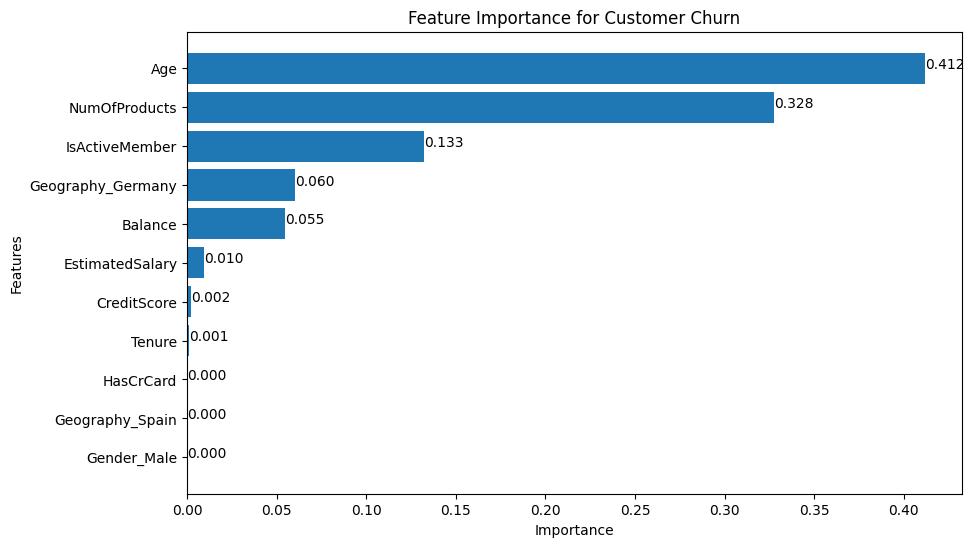

In [ ]:
# Feature Importance Visualization

plt.figure(figsize=(10, 6))

# Create the horizontal bar plot
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

# Add numerical labels to the bars
for index, value in enumerate(feature_importance["Importance"]):
    plt.text(value, index, f'{value:.3f}')

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance for Customer Churn")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# STEP 17: Final Churn Prediction

final_predictions = best_model.predict(X_test)

print("Final Churn Prediction Completed!")

print("\nFirst 20 Predictions:")
print(final_predictions[:20])

Final Churn Prediction Completed!

First 20 Predictions:
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0]


In [ ]:
# Prediction Summary

import numpy as np

churn_count = np.sum(final_predictions == 1)
no_churn_count = np.sum(final_predictions == 0)

print("Predicted Churn Customers    :", churn_count)
print("Predicted No Churn Customers :", no_churn_count)

Predicted Churn Customers    : 207
Predicted No Churn Customers : 1793


In [ ]:
# STEP 18: Final Model Performance

print("FINAL MODEL PERFORMANCE")
print("=======================")

print("Best Model:", best_model_name)

print("\nLogistic Regression:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nDecision Tree:")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

FINAL MODEL PERFORMANCE
Best Model: Decision Tree

Logistic Regression:
Accuracy : 0.808
Precision: 0.5891472868217055
Recall   : 0.18673218673218672
F1 Score : 0.2835820895522388

Decision Tree:
Accuracy : 0.856
Precision: 0.7874396135265701
Recall   : 0.4004914004914005
F1 Score : 0.5309446254071661


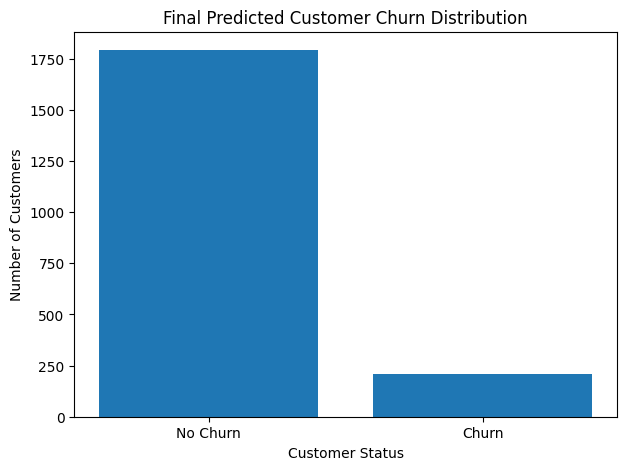

In [ ]:
# Final Churn Distribution

import matplotlib.pyplot as plt

labels = ["No Churn", "Churn"]
values = [no_churn_count, churn_count]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.title("Final Predicted Customer Churn Distribution")

plt.show()

In [ ]:
# STEP 19: Final Project Summary

print("========== FINAL PROJECT SUMMARY ==========")

print("\nBest Model:", best_model_name)

print("\nModel Performance:")
print("Logistic Regression F1 Score:", round(f1, 4))
print("Decision Tree F1 Score      :", round(dt_f1, 4))

print("\nMost Important Churn Features:")
print(feature_importance.head(5).to_string(index=False))

print("\nPredicted Customer Status:")
print("Churn    :", churn_count)
print("No Churn :", no_churn_count)

print("\n========== PROJECT COMPLETED ==========")

========== FINAL PROJECT SUMMARY ==========

Best Model: Decision Tree

Model Performance:
Logistic Regression F1 Score: 0.2836
Decision Tree F1 Score      : 0.5309

Most Important Churn Features:
          Feature  Importance
              Age    0.411949
    NumOfProducts    0.327647
   IsActiveMember    0.132522
Geography_Germany    0.060367
          Balance    0.054598

Predicted Customer Status:
Churn    : 207
No Churn : 1793

========== PROJECT COMPLETED ==========
